In [1]:
# 7-18-2026

In [2]:
# climate zones is subdivided, but i only really need the major ones or else its too granular

In [24]:
import rasterio
import numpy as np
import pandas as pd
import xarray as xr
from rasterio.enums import Resampling
import rioxarray

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

In [4]:
path = "koppen_geiger_tif/1991_2020/koppen_geiger_0p00833333.tif"

with rasterio.open(path) as src:
    print("nodata attr:", src.nodata)
    print("dtype:", src.dtypes)

    # read a coarse overview instead of the full 1km array, just to check value range fast
    data = src.read(1, out_shape=(1, src.height // 20, src.width // 20))
    vals, counts = np.unique(data, return_counts=True)
    print(dict(zip(vals, counts)))

nodata attr: 0.0
dtype: ('uint8',)
{np.uint8(0): np.int64(1559642), np.uint8(1): np.int64(19983), np.uint8(2): np.int64(14404), np.uint8(3): np.int64(53429), np.uint8(4): np.int64(69121), np.uint8(5): np.int64(19904), np.uint8(6): np.int64(26948), np.uint8(7): np.int64(28675), np.uint8(8): np.int64(6114), np.uint8(9): np.int64(3660), np.uint8(10): np.int64(15), np.uint8(11): np.int64(13074), np.uint8(12): np.int64(5065), np.uint8(13): np.int64(16), np.uint8(14): np.int64(21926), np.uint8(15): np.int64(12092), np.uint8(16): np.int64(572), np.uint8(17): np.int64(1445), np.uint8(18): np.int64(3154), np.uint8(19): np.int64(10410), np.uint8(20): np.int64(104), np.uint8(21): np.int64(4120), np.uint8(22): np.int64(7183), np.uint8(23): np.int64(13623), np.uint8(24): np.int64(1666), np.uint8(25): np.int64(9611), np.uint8(26): np.int64(48071), np.uint8(27): np.int64(93989), np.uint8(28): np.int64(832), np.uint8(29): np.int64(46664), np.uint8(30): np.int64(237288)}


In [6]:
# nan is 0

In [7]:
domains = xr.open_zarr("ecoregion_domains.zarr", consolidated=True)
print(domains)
print(domains.coords)

# check if it already carries a crs (rioxarray attaches this as an accessor, not a plain attr)
print(domains.rio.crs if hasattr(domains, "rio") else "no rio accessor, rioxarray not imported/registered yet")

<xarray.Dataset> Size: 2MB
Dimensions:    (latitude: 720, longitude: 1440)
Coordinates:
  * latitude   (latitude) float64 6kB 89.88 89.62 89.38 ... -89.38 -89.62 -89.88
  * longitude  (longitude) float64 12kB -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables:
    domain_id  (latitude, longitude) int16 2MB dask.array<chunksize=(180, 720), meta=np.ndarray>
Coordinates:
  * latitude   (latitude) float64 6kB 89.88 89.62 89.38 ... -89.38 -89.62 -89.88
  * longitude  (longitude) float64 12kB -179.9 -179.6 -179.4 ... 179.6 179.9
no rio accessor, rioxarray not imported/registered yet


In [10]:
domains = domains.rio.write_crs("EPSG:4326")
domains = domains.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")

koppen = rioxarray.open_rasterio(
    "koppen_geiger_tif/1991_2020/koppen_geiger_0p00833333.tif",
    masked=False,
).squeeze("band", drop=True)

# koppen tif band dims are x/y by default, not longitude/latitude, match names before reproject
koppen = koppen.rename({"x": "longitude", "y": "latitude"})
koppen = koppen.rio.write_crs("EPSG:4326")
koppen = koppen.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")

# mode resampling, majority class per 0.25 deg cell, matches ~900 native 1km pixels each
koppen_coarse = koppen.rio.reproject_match(
    domains,
    resampling=Resampling.mode,
)

koppen_vals = koppen_coarse.values  # shape (720, 1440), matches domain_id grid

In [11]:
# major class = first letter of the koppen code, per legend txt
legend_major = {
    1: "A", 2: "A", 3: "A",
    4: "B", 5: "B", 6: "B", 7: "B",
    8: "C", 9: "C", 10: "C", 11: "C", 12: "C", 13: "C", 14: "C", 15: "C", 16: "C",
    17: "D", 18: "D", 19: "D", 20: "D", 21: "D", 22: "D", 23: "D", 24: "D", 25: "D", 26: "D", 27: "D", 28: "D",
    29: "E", 30: "E",
}

major_classes = ["A", "B", "C", "D", "E"]

In [12]:
# remap subdivision codes to major class codes, keep 0 as nodata
remap = np.zeros(31, dtype="U1")  # index by raw code 0-30
for code, major in legend_major.items():
    remap[code] = major

koppen_major = remap[koppen_vals]  # shape (720, 1440), string array of "A".."E" or ""

In [13]:
used_domains = [0, 1, 2, 4, 5, 6, 7, 8, 11, 12, 13, 16, 18, 19, 20, 21, 22, 23,
                25, 26, 27, 28, 29, 30, 32, 33, 36, 37, 38, 39, 45, 46, 47, 49]

domain_vals = domains["domain_id"].values

In [ ]:
major_order = ["A", "B", "C", "D", "E"]
major_to_int = {c: i for i, c in enumerate(major_order)}

# koppen_major is a string array, need it numeric to plot, "" (nodata) -> -1
plot_grid = np.full(koppen_major.shape, -1, dtype=int)
for c, i in major_to_int.items():
    plot_grid[koppen_major == c] = i

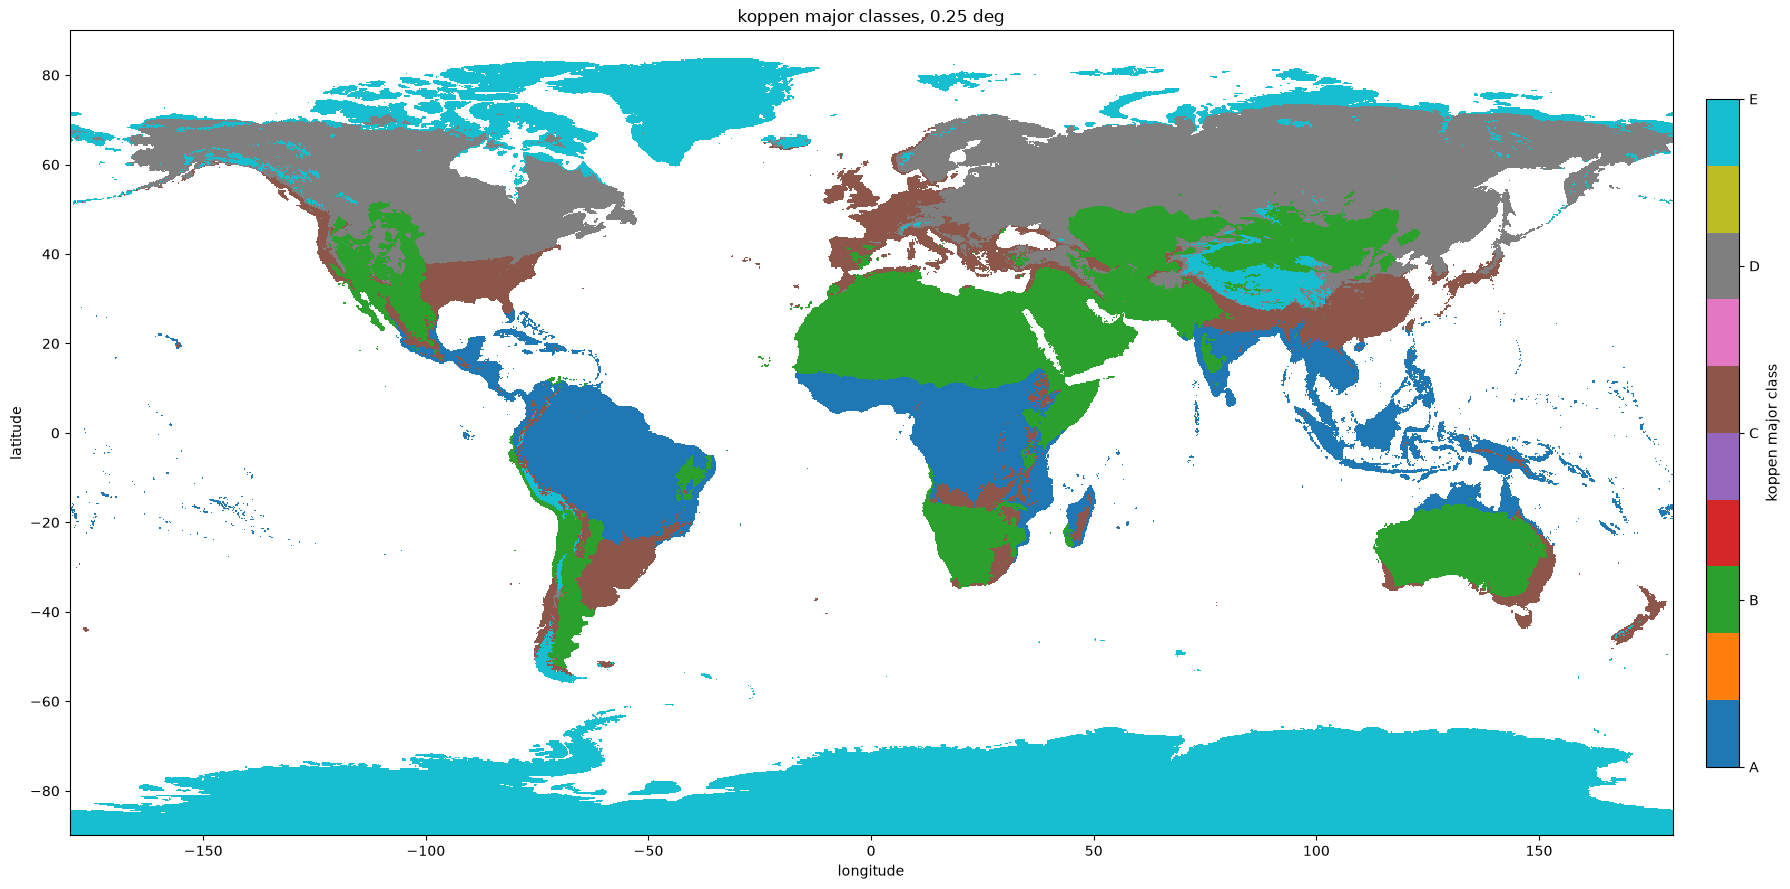

In [26]:
cmap = plt.cm.tab10
cmap.set_under("white")  # nodata cells stay white

fig, ax = plt.subplots(figsize=(18, 9))
img = ax.imshow(
    plot_grid,
    origin="upper",
    extent=[-180, 180, -90, 90],
    cmap=cmap,
    vmin=0, vmax=len(major_order) - 1,
    interpolation="none",
    aspect="auto",
)
cbar = fig.colorbar(img, ax=ax, ticks=range(len(major_order)), fraction=0.02, pad=0.02)
cbar.ax.set_yticklabels(major_order)
cbar.set_label("koppen major class")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("koppen major classes, 0.25 deg")
plt.tight_layout()
plt.show()

In [15]:
print(koppen_vals.shape, domain_vals.shape)
assert koppen_vals.shape == domain_vals.shape

(720, 1440) (720, 1440)


In [16]:
vals, counts = np.unique(koppen_vals, return_counts=True)
print(dict(zip(vals, counts)))

{np.uint8(0): np.int64(671500), np.uint8(1): np.int64(11533), np.uint8(2): np.int64(7455), np.uint8(3): np.int64(25673), np.uint8(4): np.int64(31806), np.uint8(5): np.int64(8861), np.uint8(6): np.int64(12254), np.uint8(7): np.int64(12936), np.uint8(8): np.int64(3437), np.uint8(9): np.int64(1838), np.uint8(10): np.int64(1), np.uint8(11): np.int64(5888), np.uint8(12): np.int64(2169), np.uint8(13): np.int64(3), np.uint8(14): np.int64(10660), np.uint8(15): np.int64(6610), np.uint8(16): np.int64(356), np.uint8(17): np.int64(549), np.uint8(18): np.int64(1438), np.uint8(19): np.int64(4522), np.uint8(20): np.int64(27), np.uint8(21): np.int64(1935), np.uint8(22): np.int64(3184), np.uint8(23): np.int64(5931), np.uint8(24): np.int64(756), np.uint8(25): np.int64(4290), np.uint8(26): np.int64(21982), np.uint8(27): np.int64(43532), np.uint8(28): np.int64(375), np.uint8(29): np.int64(27186), np.uint8(30): np.int64(108113)}


In [17]:
print(np.unique(koppen_major))

['' 'A' 'B' 'C' 'D' 'E']


In [18]:
for code in [1, 4, 14, 26, 29]:
    print(code, "->", remap[code])

1 -> A
4 -> B
14 -> C
26 -> D
29 -> E


In [19]:
d = 45
mask = domain_vals == d
dom_classes = koppen_major[mask]
dom_classes = dom_classes[dom_classes != ""]
print(f"domain {d}: {len(dom_classes)} covered cells out of {mask.sum()} total")
vals, counts = np.unique(dom_classes, return_counts=True)
print(dict(zip(vals, counts)))

domain 45: 3617 covered cells out of 3617 total
{np.str_('A'): np.int64(2621), np.str_('B'): np.int64(996)}


In [20]:
for d in used_domains:
    mask = domain_vals == d
    total = mask.sum()
    covered = (koppen_major[mask] != "").sum()
    if total > 0 and covered / total < 0.5:
        print(f"domain {d}: only {covered}/{total} cells covered, check this one")

In [ ]:
# csv 1: dominant major class, 60% threshold
dominant_rows = []
for d in used_domains:
    mask = domain_vals == d
    dom_classes = koppen_major[mask]
    dom_classes = dom_classes[dom_classes != ""]  # drop nodata

    if len(dom_classes) == 0:
        continue

    vals, counts = np.unique(dom_classes, return_counts=True)
    top_idx = np.argmax(counts)
    top_class, top_frac = vals[top_idx], counts[top_idx] / len(dom_classes)

    if top_frac > 0.5:
        dominant_rows.append({
            "domain": d,
            "dominant_koppen": top_class,
            "fraction": round(top_frac, 4),
            "n_covered_cells": len(dom_classes),
        })

print(f"{len(dominant_rows)} / {len(used_domains)} domains mapped to a zone")

pd.DataFrame(dominant_rows).to_csv("domain_dominant_koppen.csv", index=False)

# 21/34 domains got mapped when thers >60%
# 30/34 when 50%

30 / 34 domains mapped to a zone


In [23]:
# csv 2: full major class fraction vector, all 34 domains
vector_rows = []
for d in used_domains:
    mask = domain_vals == d
    total_cells = mask.sum()
    dom_classes = koppen_major[mask]
    dom_classes = dom_classes[dom_classes != ""]

    row = {"domain": d, "total_cells": int(total_cells), "covered_cells": len(dom_classes)}
    row["coverage_pct"] = round(len(dom_classes) / total_cells, 4) if total_cells > 0 else 0.0

    if len(dom_classes) > 0:
        vals, counts = np.unique(dom_classes, return_counts=True)
        fracs = dict(zip(vals, counts / len(dom_classes)))
    else:
        fracs = {}

    for c in major_classes:
        row[f"koppen_{c}_pct"] = round(fracs.get(c, 0.0), 4)

    vector_rows.append(row)

pd.DataFrame(vector_rows).to_csv("domain_koppen_vectors.csv", index=False)